In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

df = pd.read_csv("diabetes.csv")

print(df.head())

print("Shape of dataset:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())


print("Dataset Information:")
df.info()

print(df.describe())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
Shape of dataset:
(768, 9)

Column names:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column

In [8]:
#missing values
print("Missing values:")
print(df.isnull().sum())


zero_counts = (df == 0).sum()

print("Number of zero values in each column:")
print(zero_counts)

#handle
columns_with_zero = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI'
]

df[columns_with_zero] = df[columns_with_zero].replace(0, np.nan)

print("Missing values after replacing invalid zeros:")
print(df.isnull().sum())


#filling
for column in columns_with_zero:
    df[column] = df[column].fillna(df[column].median())

print("Missing values after median imputation:")
print(df.isnull().sum())

Missing values:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64
Number of zero values in each column:
Pregnancies                 111
Glucose                       0
BloodPressure                 0
SkinThickness                 0
Insulin                       0
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64
Missing values after replacing invalid zeros:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int

In [11]:

#duplicate values
print("Number of duplicate rows:")
print(df.duplicated().sum())

#drop
df = df.drop_duplicates()

print("Shape after removing duplicates:")
print(df.shape)


print(df['Outcome'].value_counts())

Number of duplicate rows:
0
Shape after removing duplicates:
(768, 9)
Outcome
0    500
1    268
Name: count, dtype: int64


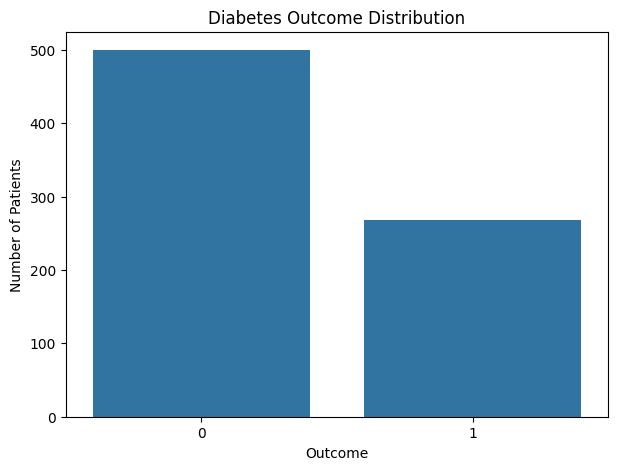

In [12]:
#EDA  Outcome Distribution
plt.figure(figsize=(7, 5))

sns.countplot(x='Outcome', data=df)

plt.title("Diabetes Outcome Distribution")
plt.xlabel("Outcome")
plt.ylabel("Number of Patients")

plt.show()

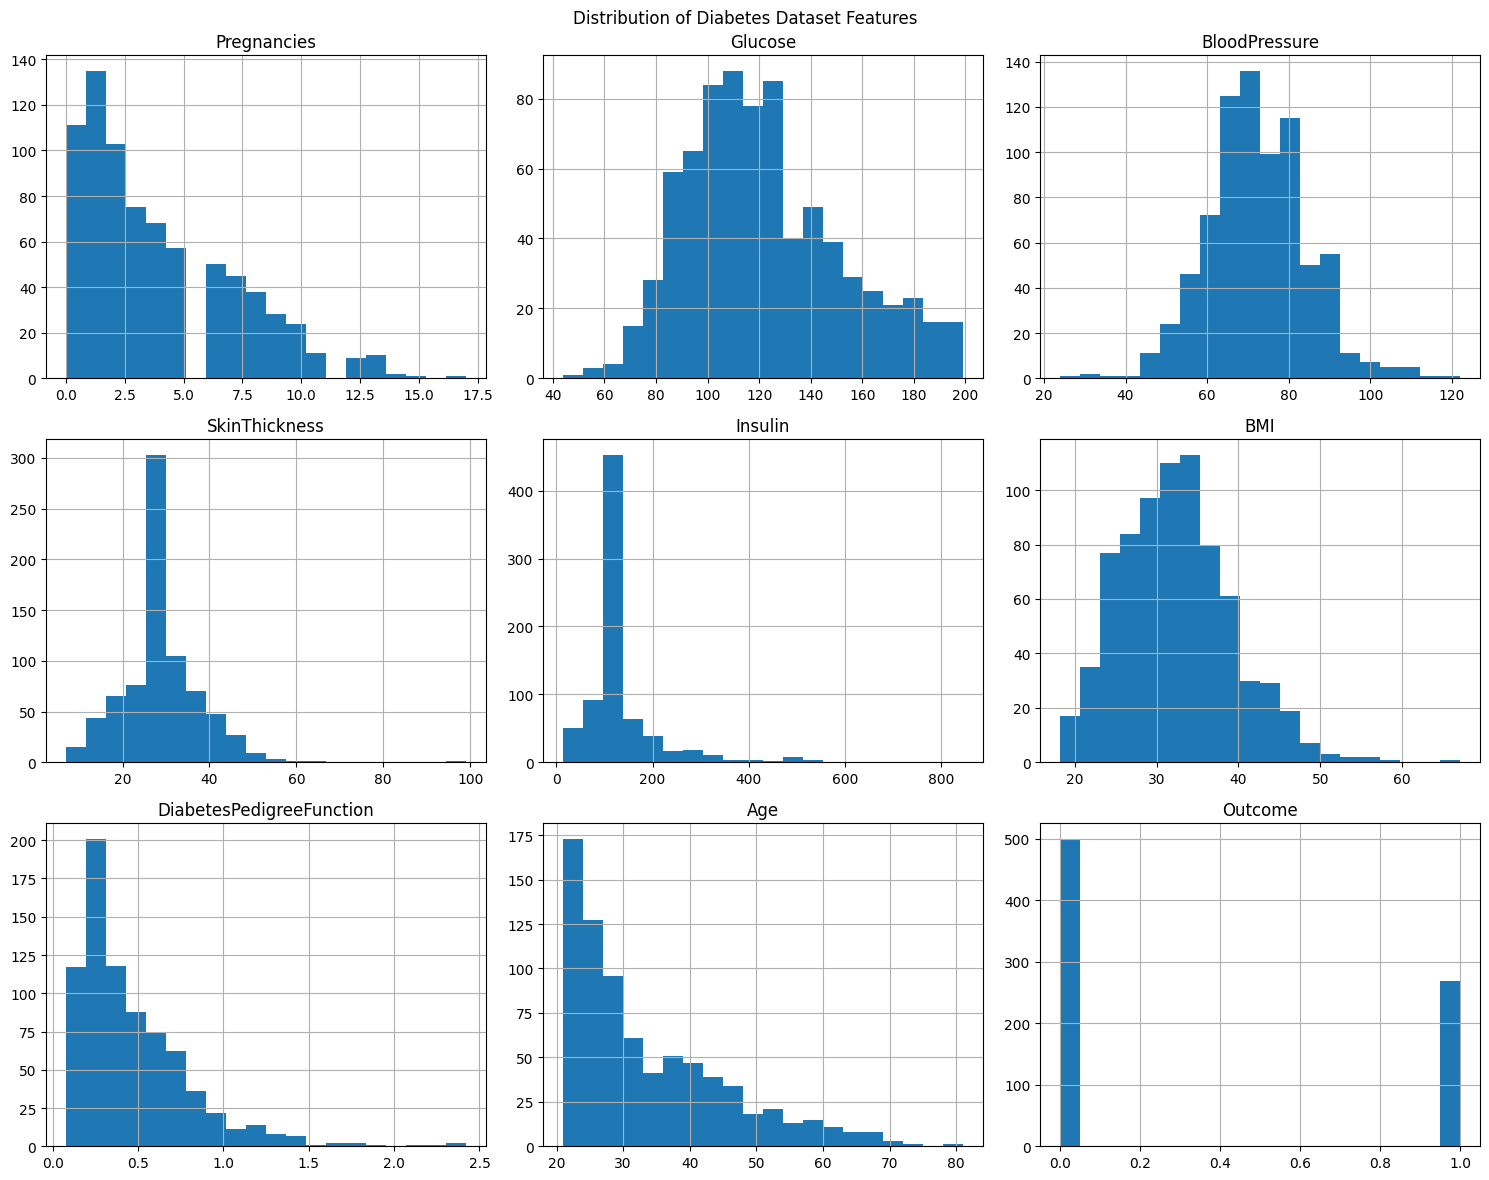

In [13]:
#Histogram
df.hist(
    figsize=(15, 12),
    bins=20
)

plt.suptitle("Distribution of Diabetes Dataset Features")

plt.tight_layout()

plt.show()

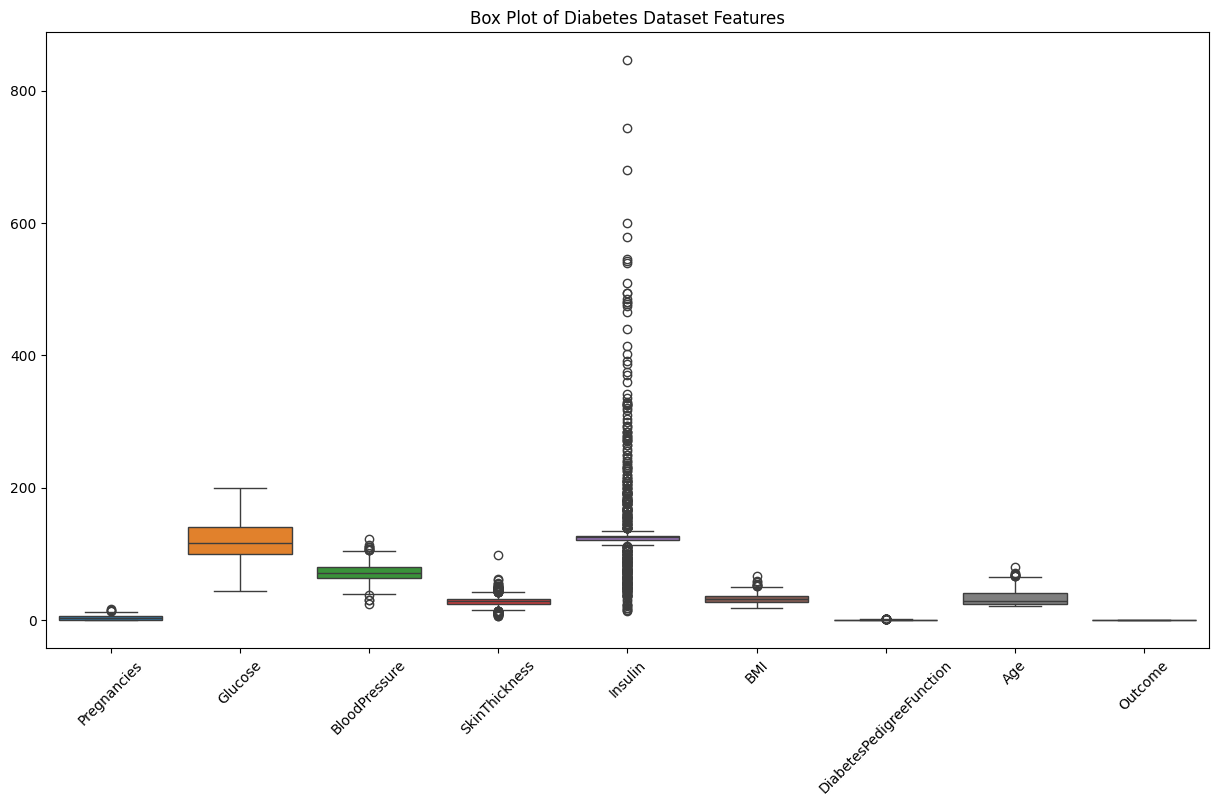

In [14]:
#box plot
plt.figure(figsize=(15, 8))

sns.boxplot(data=df)

plt.title("Box Plot of Diabetes Dataset Features")

plt.xticks(rotation=45)

plt.show()

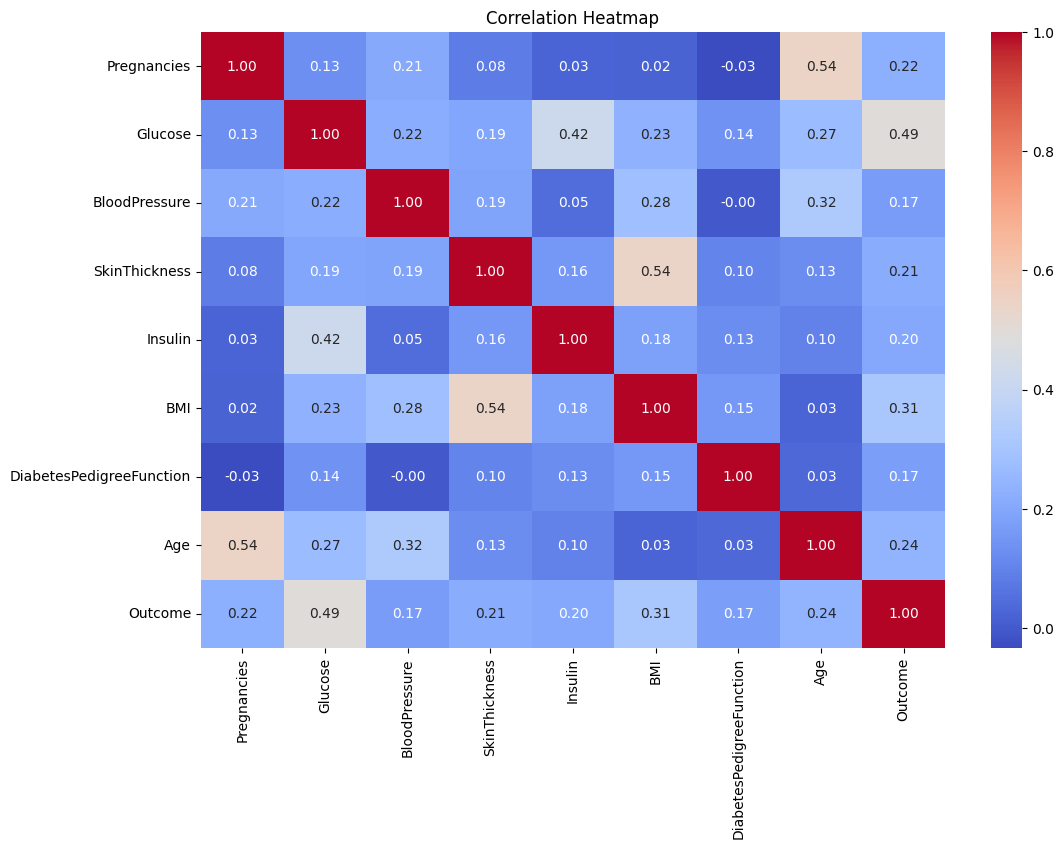

In [16]:
#Correlation Heatmap
plt.figure(figsize=(12, 8))

correlation = df.corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")

plt.show()

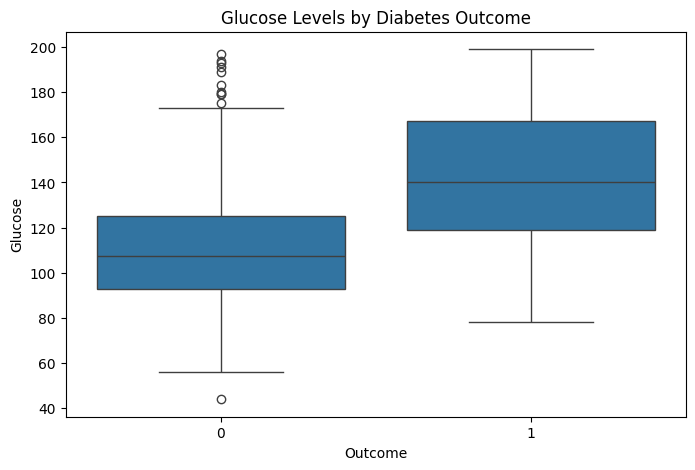

In [17]:
#Glucose vs Outcome
plt.figure(figsize=(8, 5))

sns.boxplot(
    x='Outcome',
    y='Glucose',
    data=df
)

plt.title("Glucose Levels by Diabetes Outcome")

plt.xlabel("Outcome")
plt.ylabel("Glucose")

plt.show()

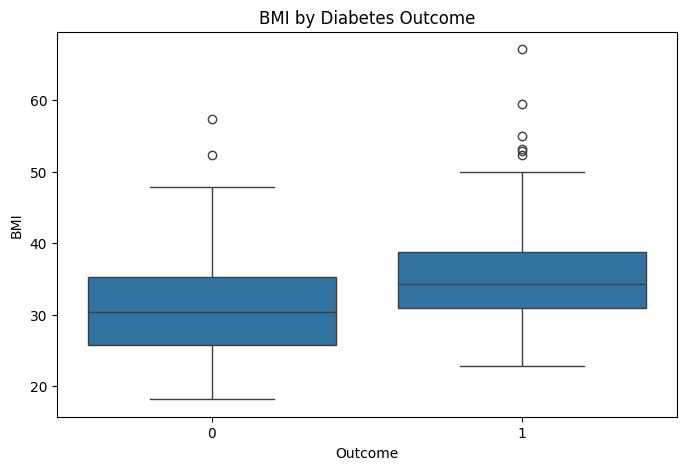

In [18]:
#BMI vs Outcome
plt.figure(figsize=(8, 5))

sns.boxplot(
    x='Outcome',
    y='BMI',
    data=df
)

plt.title("BMI by Diabetes Outcome")

plt.xlabel("Outcome")
plt.ylabel("BMI")

plt.show()

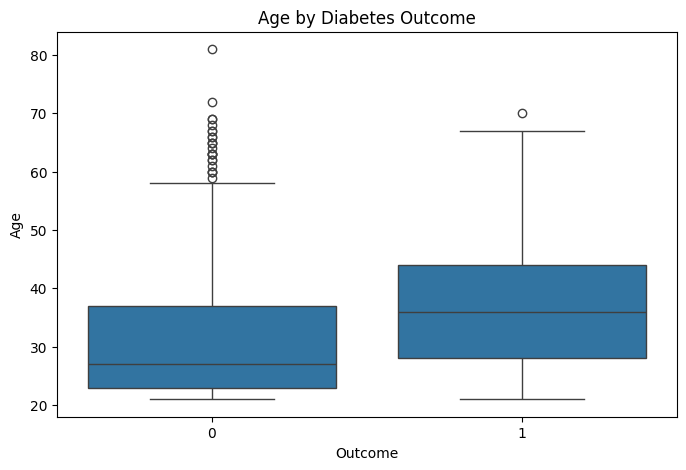

In [19]:
#Age
plt.figure(figsize=(8, 5))

sns.boxplot(
    x='Outcome',
    y='Age',
    data=df
)

plt.title("Age by Diabetes Outcome")

plt.xlabel("Outcome")
plt.ylabel("Age")

plt.show()

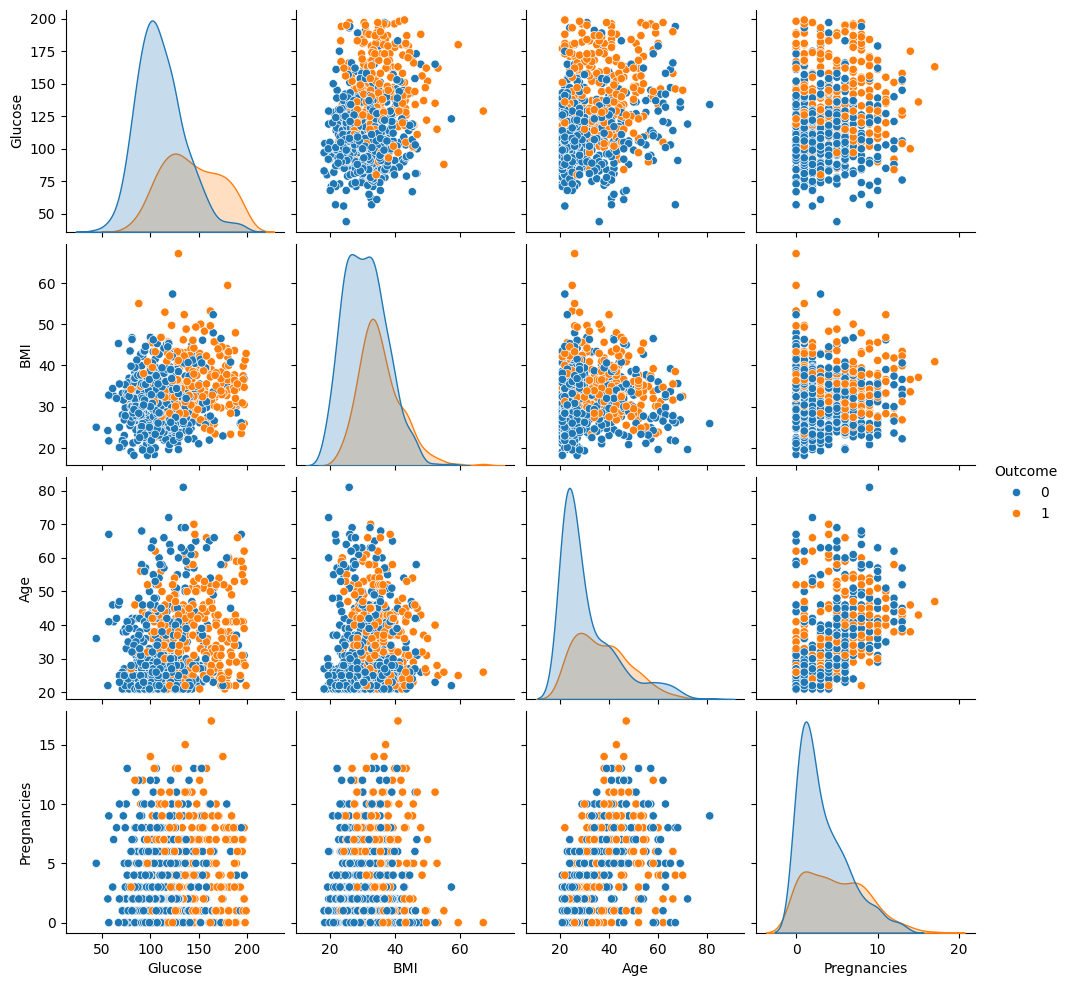

In [20]:
#Pair Plot
sns.pairplot(
    df[
        [
            'Glucose',
            'BMI',
            'Age',
            'Pregnancies',
            'Outcome'
        ]
    ],
    hue='Outcome'
)

plt.show()

In [30]:
X = df.drop('Outcome', axis=1)

y = df['Outcome']

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())


#train test

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)


#standardize
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)


#build model
logistic_model = LogisticRegression(
    max_iter=1000
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

#make predictions
y_pred = logistic_model.predict(X_test_scaled)

print("Predictions:")
print(y_pred[:20])


#predicting probabilities
y_probability = logistic_model.predict_proba(X_test_scaled)[:, 1]

print("First 10 predicted probabilities:")
print(y_probability[:10])


#accuracy
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

#precision
precision = precision_score(
    y_test,
    y_pred
)

print("Precision:", precision)

#recall

recall = recall_score(
    y_test,
    y_pred
)

print("Recall:", recall)


#F1 score
f1 = f1_score(
    y_test,
    y_pred
)

print("F1 Score:", f1)


#ROC-AUC Score

roc_auc = roc_auc_score(
    y_test,
    y_probability
)

print("ROC-AUC Score:", roc_auc)

Features:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6    148.0           72.0           35.0    125.0  33.6   
1            1     85.0           66.0           29.0    125.0  26.6   
2            8    183.0           64.0           29.0    125.0  23.3   
3            1     89.0           66.0           23.0     94.0  28.1   
4            0    137.0           40.0           35.0    168.0  43.1   

   DiabetesPedigreeFunction  Age  
0                     0.627   50  
1                     0.351   31  
2                     0.672   32  
3                     0.167   21  
4                     2.288   33  

Target:
0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64
Training data: (614, 8)
Testing data: (154, 8)
Predictions:
[1 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 1 0 1 0]
First 10 predicted probabilities:
[0.60971073 0.11835576 0.29346313 0.2508367  0.03320667 0.16852385
 0.4881643  0.92367511 0.08143405 0.8385896 ]
Accuracy: 0.70779220779220

In [31]:
#Display All Evaluation Metrics Together
results = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score',
        'ROC-AUC'
    ],
    'Score': [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

print(results)

      Metric     Score
0   Accuracy  0.707792
1  Precision  0.600000
2     Recall  0.500000
3   F1 Score  0.545455
4    ROC-AUC  0.812963


Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



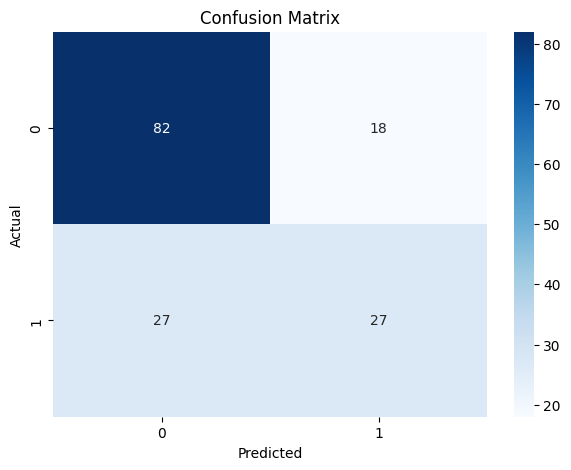

In [33]:
#Classification Report
print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred
    )
)


#Confusion Matrix
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

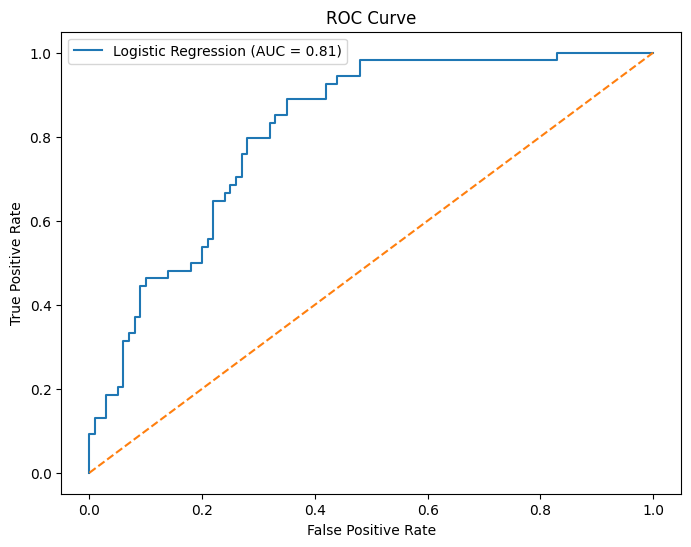

In [35]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probability
)

#plot
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f'Logistic Regression (AUC = {roc_auc:.2f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [40]:
#coefficients
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': logistic_model.coef_[0]
})

print(coefficients)


#odd
coefficients['Odds_Ratio'] = np.exp(
    coefficients['Coefficient']
)

print(coefficients)


                    Feature  Coefficient
0               Pregnancies     0.377502
1                   Glucose     1.182511
2             BloodPressure    -0.044066
3             SkinThickness     0.028225
4                   Insulin    -0.066157
5                       BMI     0.688735
6  DiabetesPedigreeFunction     0.233386
7                       Age     0.147798
                    Feature  Coefficient  Odds_Ratio
0               Pregnancies     0.377502    1.458637
1                   Glucose     1.182511    3.262558
2             BloodPressure    -0.044066    0.956891
3             SkinThickness     0.028225    1.028627
4                   Insulin    -0.066157    0.935983
5                       BMI     0.688735    1.991194
6  DiabetesPedigreeFunction     0.233386    1.262869
7                       Age     0.147798    1.159279


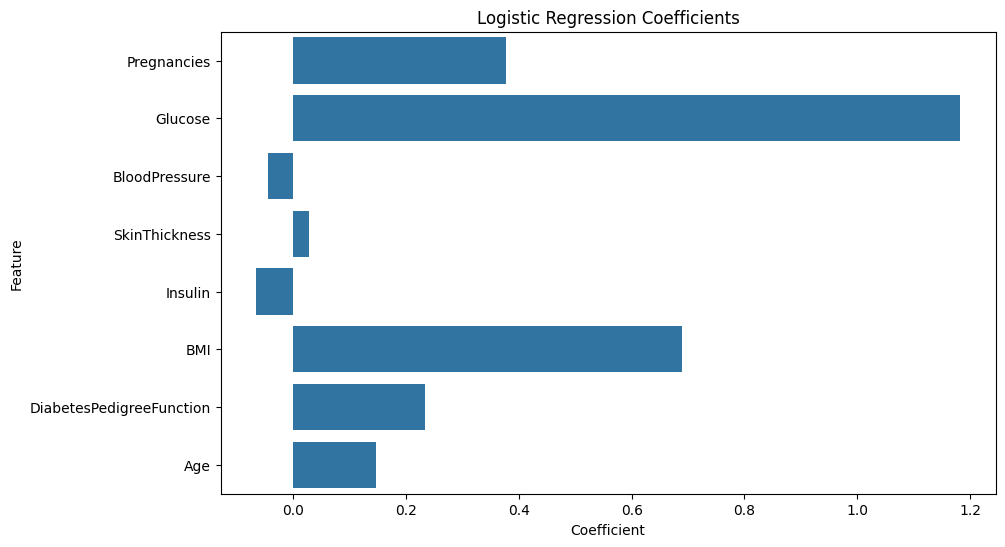

In [41]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=coefficients,
    x='Coefficient',
    y='Feature'
)

plt.title("Logistic Regression Coefficients")

plt.show()

# **Interpretation**


The logistic regression coefficients indicate the direction of association between each predictor and the probability of diabetes.

Positive coefficients indicate that increasing the corresponding feature is associated with higher log-odds of diabetes, while negative coefficients indicate lower log-odds, when other variables are held constant.

The magnitude of a coefficient should be interpreted carefully because the predictors have been standardized. The odds ratio provides a more intuitive interpretation of the effect on the odds of diabetes.

# **Important Assumptions**

## Assumptions

1. The target variable is binary.
2. Observations are assumed to be independent.
3. The relationship between continuous predictors and the log-odds of the outcome is assumed to be approximately linear.
4. Severe multicollinearity among predictors should be avoided.
5. The training data should be representative of the data on which predictions will be made.

# **Final Conclusion**

A logistic regression model was developed to predict diabetes status using medical and demographic features. Exploratory data analysis was performed using statistical summaries, histograms, box plots, pair plots, and a correlation heatmap.

Missing or invalid zero values in selected medical variables were treated as missing values and replaced using median imputation. The categorical-variable encoding step was included as part of the preprocessing workflow, although the provided diabetes dataset contains numerical predictor variables. The data was divided into training and testing sets using an 80:20 ratio, with stratification to preserve the class distribution.

The features were standardized before fitting the logistic regression model. The model was evaluated using accuracy, precision, recall, F1-score, ROC-AUC, a confusion matrix, and an ROC curve.

The model coefficients were examined to understand which features were positively or negatively associated with the probability of diabetes. Features with positive coefficients increase the log-odds of diabetes, while negative coefficients decrease the log-odds when other variables are held constant.

Overall, logistic regression provides an interpretable binary classification approach for predicting diabetes status from the available patient characteristics.

# **Interview Questions**

**What is the difference between Precision and Recall?**

## Interview Question 1

### Precision

Precision measures how many of the observations predicted as positive are actually positive.

Precision = True Positives / (True Positives + False Positives)

A high precision means the model produces fewer false positive predictions.

### Recall

Recall measures how many of the actual positive observations were correctly identified by the model.

Recall = True Positives / (True Positives + False Negatives)

A high recall means the model produces fewer false negative predictions.

### Difference

Precision focuses on the correctness of positive predictions, while recall focuses on finding as many actual positive cases as possible.

For medical diagnosis, recall can be particularly important because missing an actual positive patient (false negative) can have serious consequences.

**What is Cross-Validation and Why Is It Important?**

## Interview Question 2

### Cross-Validation

Cross-validation is a technique used to evaluate how well a machine learning model is expected to perform on unseen data.

In k-fold cross-validation, the dataset is divided into k parts. The model is trained using k-1 parts and evaluated on the remaining part. This process is repeated until every part has been used as the validation set.

### Why is it important?

Cross-validation is important because a single train-test split may give a performance estimate that depends on the particular observations selected for the test set.

Cross-validation provides a more reliable estimate of model performance and can help identify overfitting. It can also be used to select model hyperparameters.

For binary classification, stratified k-fold cross-validation is commonly preferred because it maintains a similar proportion of the two target classes in each fold.

In [42]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import joblib

final_model = Pipeline([
    ('scaler', StandardScaler()),
    ('logistic_regression', LogisticRegression(max_iter=1000))
])

final_model.fit(X_train, y_train)

joblib.dump(final_model, 'diabetes_logistic_model.pkl')

print("Model saved successfully!")

Model saved successfully!


In [43]:
from google.colab import files

files.download('diabetes_logistic_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Streamlit Deployment**

The trained logistic regression model was deployed using Streamlit.

The Streamlit application allows users to enter patient information such as:

- Pregnancies
- Glucose
- Blood Pressure
- Skin Thickness
- Insulin
- BMI
- Diabetes Pedigree Function
- Age

After entering the information and clicking the Predict button, the application uses the trained logistic regression model to predict the diabetes outcome and display the probability of diabetes.

The application was successfully tested locally using Streamlit.